/tmp/ipykernel_749797/2560054652.py:96: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(disease_keys))


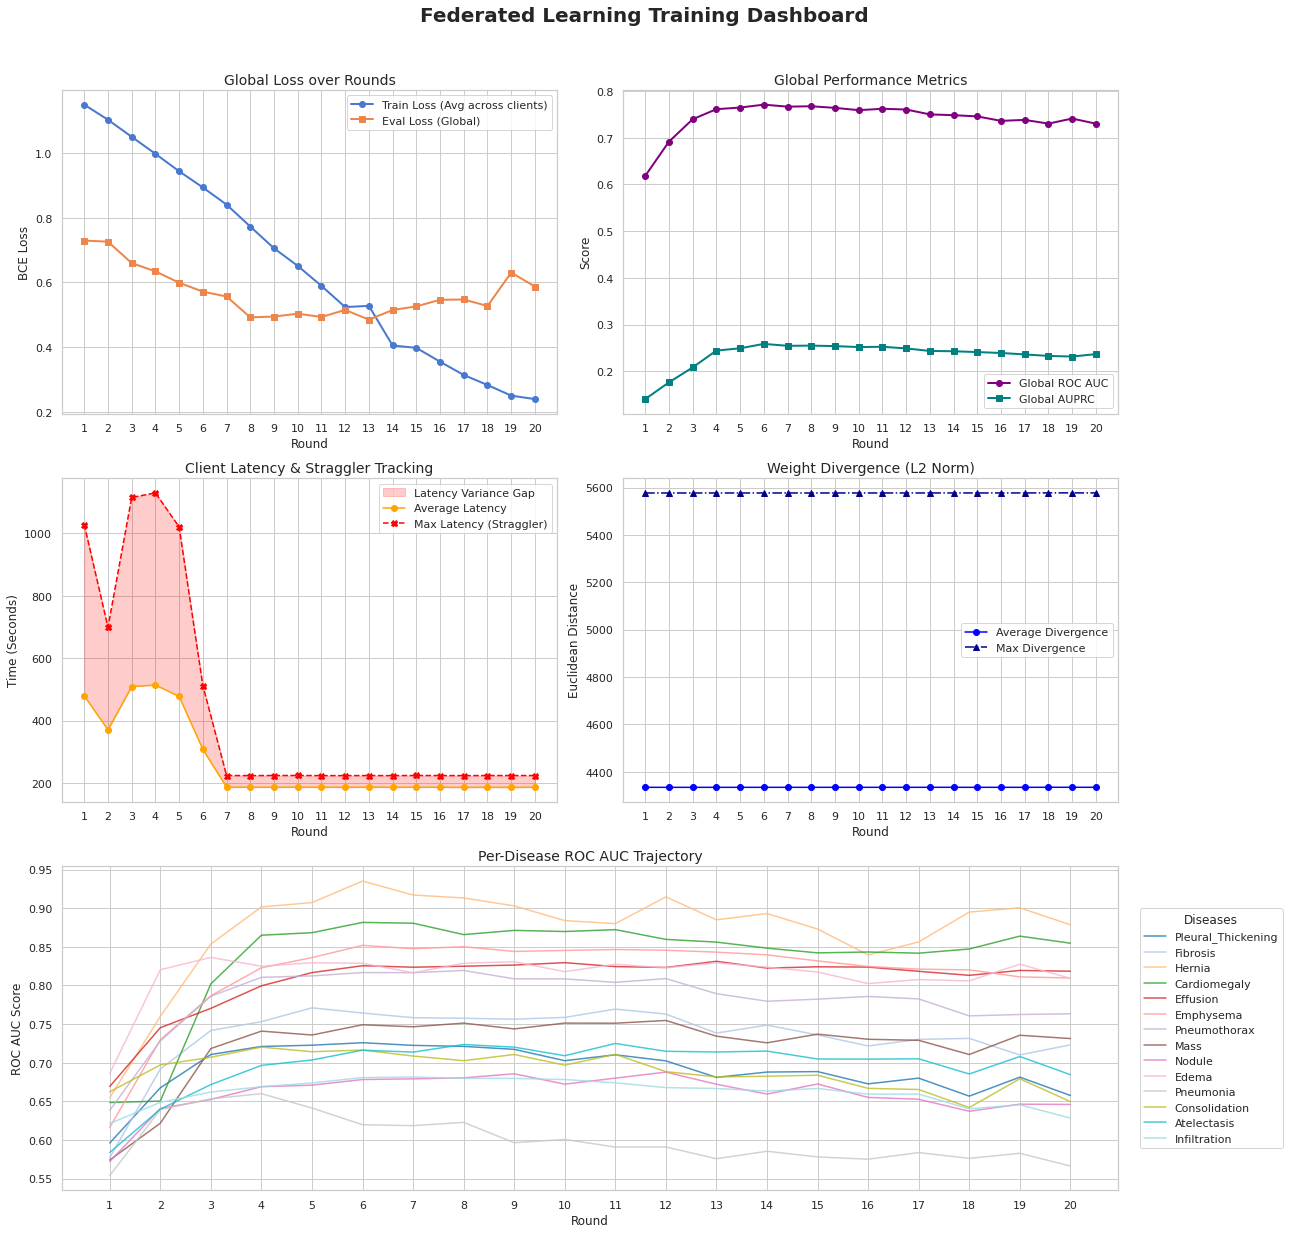

--------------------------------------------------
FINAL ROUND SUMMARY:
--------------------------------------------------
Final Eval Loss:    0.5873
Final Global AUC:   0.7301
Final Global AUPRC: 0.2370

Top 3 Performing Diseases (AUC):
 - Hernia: 0.8786
 - Cardiomegaly: 0.8548
 - Effusion: 0.8185

Bottom 3 Performing Diseases (AUC):
 - Nodule: 0.6460
 - Infiltration: 0.6283
 - Pneumonia: 0.5663
--------------------------------------------------


In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid", palette="muted")

def load_and_extract(filepath):
    """Loads JSON and provides a helper to extract X (rounds) and Y (values)."""
    with open(filepath, 'r') as f:
        data = json.load(f)
        
    def extract_xy(metric_data):
        if not metric_data: return [], []
        rounds = [item[0] for item in metric_data]
        values = [item[1] for item in metric_data]
        return rounds, values
        
    return data, extract_xy

def plot_federated_dashboard(filepath="federated_metrics.json"):
    data, get_xy = load_and_extract(filepath)
    
    fig = plt.figure(figsize=(18, 18))
    fig.suptitle("Federated Learning Training Dashboard", fontsize=20, y=0.98, fontweight='bold')

    # ==========================================
    # 1. Loss Curve (Train vs Eval)
    # ==========================================
    ax1 = fig.add_subplot(3, 2, 1)
    train_x, train_y = get_xy(data['metrics_distributed_fit']['avg_train_loss'])
    eval_x, eval_y = get_xy(data['losses_distributed'])
    
    ax1.plot(train_x, train_y, label='Train Loss (Avg across clients)', marker='o', linewidth=2)
    ax1.plot(eval_x, eval_y, label='Eval Loss (Global)', marker='s', linewidth=2)
    ax1.set_title('Global Loss over Rounds', fontsize=14)
    ax1.set_xlabel('Round')
    ax1.set_ylabel('BCE Loss')
    ax1.set_xticks(train_x)
    ax1.legend()

    # ==========================================
    # 2. Global Evaluation Metrics (AUC & AUPRC)
    # ==========================================
    ax2 = fig.add_subplot(3, 2, 2)
    auc_x, auc_y = get_xy(data['metrics_distributed']['global_auc'])
    auprc_x, auprc_y = get_xy(data['metrics_distributed']['global_auprc'])
    
    ax2.plot(auc_x, auc_y, label='Global ROC AUC', marker='o', color='purple', linewidth=2)
    ax2.plot(auprc_x, auprc_y, label='Global AUPRC', marker='s', color='teal', linewidth=2)
    ax2.set_title('Global Performance Metrics', fontsize=14)
    ax2.set_xlabel('Round')
    ax2.set_ylabel('Score')
    ax2.set_xticks(auc_x)
    ax2.legend()

    # ==========================================
    # 3. Straggler Analysis (Latency)
    # ==========================================
    ax3 = fig.add_subplot(3, 2, 3)
    avg_lat_x, avg_lat_y = get_xy(data['metrics_distributed_fit']['avg_latency'])
    max_lat_x, max_lat_y = get_xy(data['metrics_distributed_fit']['max_latency'])
    
    ax3.fill_between(avg_lat_x, avg_lat_y, max_lat_y, alpha=0.2, color='red', label='Latency Variance Gap')
    ax3.plot(avg_lat_x, avg_lat_y, label='Average Latency', marker='o', color='orange')
    ax3.plot(max_lat_x, max_lat_y, label='Max Latency (Straggler)', marker='X', color='red', linestyle='--')
    ax3.set_title('Client Latency & Straggler Tracking', fontsize=14)
    ax3.set_xlabel('Round')
    ax3.set_ylabel('Time (Seconds)')
    ax3.set_xticks(avg_lat_x)
    ax3.legend()

    # ==========================================
    # 4. Weight Divergence
    # ==========================================
    ax4 = fig.add_subplot(3, 2, 4)
    avg_div_x, avg_div_y = get_xy(data['metrics_distributed_fit']['avg_weight_divergence'])
    max_div_x, max_div_y = get_xy(data['metrics_distributed_fit']['max_weight_divergence'])
    
    ax4.plot(avg_div_x, avg_div_y, label='Average Divergence', marker='o', color='blue')
    ax4.plot(max_div_x, max_div_y, label='Max Divergence', marker='^', color='darkblue', linestyle='-.')
    ax4.set_title('Weight Divergence (L2 Norm)', fontsize=14)
    ax4.set_xlabel('Round')
    ax4.set_ylabel('Euclidean Distance')
    ax4.set_xticks(avg_div_x)
    ax4.legend()

    # ==========================================
    # 5. Per-Disease AUC Trajectory
    # ==========================================
    ax5 = fig.add_subplot(3, 1, 3) # Span the bottom row
    disease_keys = [k for k in data['metrics_distributed'].keys() if k.startswith('auc_') and not k.endswith('_variance')]
    
    # Use a broad colormap to distinguish 14 diseases
    cmap = plt.cm.get_cmap('tab20', len(disease_keys))
    
    final_aucs = {}
    for i, key in enumerate(disease_keys):
        disease_name = key.replace('auc_', '')
        x, y = get_xy(data['metrics_distributed'][key])
        ax5.plot(x, y, label=disease_name, color=cmap(i), alpha=0.8, linewidth=1.5)
        final_aucs[disease_name] = y[-1] # Store final round AUC for printing/sorting

    ax5.set_title('Per-Disease ROC AUC Trajectory', fontsize=14)
    ax5.set_xlabel('Round')
    ax5.set_ylabel('ROC AUC Score')
    ax5.set_xticks(train_x)
    
    # Put legend outside the plot so it doesn't overlap lines
    ax5.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="Diseases", borderaxespad=0.)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to make room for suptitle
    plt.show()

    # ==========================================
    # Print a text summary of the final round
    # ==========================================
    print("-" * 50)
    print("FINAL ROUND SUMMARY:")
    print("-" * 50)
    final_round = train_x[-1]
    print(f"Final Eval Loss:    {eval_y[-1]:.4f}")
    print(f"Final Global AUC:   {auc_y[-1]:.4f}")
    print(f"Final Global AUPRC: {auprc_y[-1]:.4f}")
    print("\nTop 3 Performing Diseases (AUC):")
    
    # Sort diseases by final AUC
    sorted_diseases = sorted(final_aucs.items(), key=lambda item: item[1], reverse=True)
    for name, score in sorted_diseases[:3]:
        print(f" - {name}: {score:.4f}")
        
    print("\nBottom 3 Performing Diseases (AUC):")
    for name, score in sorted_diseases[-3:]:
        print(f" - {name}: {score:.4f}")
    print("-" * 50)

# Execute the visualization
plot_federated_dashboard("federated_metrics.json")